In [3]:
# load packages
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import colors
#mpl.rcParams['figure.dpi'] = 300
from cellpose import models, io, plot
from tifffile import imread, imwrite
from skimage import morphology
from scipy import ndimage as ndi

In [28]:
# loading images
path = r"C:\Users\zuzka\Desktop\2023_Vishma_FLIM_NADPH_sperms"

# path alternatives
# folder_name = '2023-05-12_analysis_processed'
folder_name = '2023-04-27_Zeiss_renamed_processed'


In [54]:
def custom_sorting(x):
    if isinstance(x, str) and "5887" in x:
        return 'z' + x
    return x

In [59]:
files_cell = [k for k in os.listdir(path + r'/' + folder_name) if k.endswith("i01.tif")]
files_cell = sorted(files_cell, key = custom_sorting)
files_list = [a.replace('i01.tif', 'S') for a in files_cell]

['Normo_Plate_01S',
 'Normo_Plate_02S',
 'Normo_Plate_03S',
 'Normo_Plate_04S',
 'Normo_Plate_05S',
 'Normo_Plate_06S',
 'Normo_Plate_07S',
 'Normo_Plate_08S',
 'Normo_Plate_09S',
 'Normo_Plate_10S',
 'Normo_Plate_11S',
 'Normo_Plate_12S',
 'Normo_Plate_13S',
 'Patho_Plate_14S',
 'Patho_Plate_15S',
 'Patho_Plate_16S',
 'Patho_Plate_17S',
 'Patho_Plate_18S',
 'Patho_Plate_19S',
 'Patho_Plate_20S',
 'Patho_Plate_21S',
 'Patho_Plate_22S',
 'Patho_Plate_23S',
 'Patho_Plate_24S',
 'Patho_Plate_25S',
 'Patho_Plate_26S',
 'Patient_59_Plate_4_57S',
 'Patient_59_Plate_4_58S',
 'Patient_59_Plate_4_59S',
 'Patient_59_Plate_4_60S',
 'Patient_59_Plate_4_61S',
 'Patient_59_Plate_4_62S',
 'Patient_59_Plate_4_63S',
 'Patient_59_Plate_4_64S',
 'Patient_5887_Plate_27S',
 'Patient_5887_Plate_28S',
 'Patient_5887_Plate_29S',
 'Patient_5887_Plate_2_38S',
 'Patient_5887_Plate_2_39S',
 'Patient_5887_Plate_2_40S',
 'Patient_5887_Plate_2_41S',
 'Patient_5887_Plate_2_42S',
 'Patient_5887_Plate_2_43S',
 'Patient

In [61]:
file_path = path+'/file_list.txt'

with open(file_path, 'w') as file:
    for item in files_list:
        file.write(str(item) + '\n')

In [63]:
imgs_cell = [imread(path + r'/' + folder_name + r'/' + filename) for filename in files_cell]

In [31]:
# create list of image names
# names = [(iname.split(' ')[0]).replace('d3', 'd1') for iname in files_ch1]

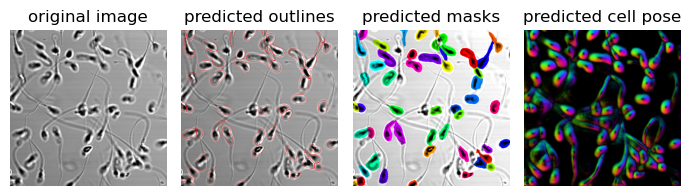

In [64]:
# show one image

model = models.CellposeModel(gpu=True, model_type='cyto')

# specify channel for segmentation
channels = [0,0]

# run model
# diameter is set
i = 20
masks, flows, styles = model.eval(imgs_cell[i], diameter=30, channels=channels, flow_threshold = 0.4)

fig = plt.figure(figsize=(7,5))
plot.show_segmentation(fig, imgs_cell[i], masks, flows[0], channels=channels)
plt.tight_layout()
plt.show()

In [65]:
# run model on all

model = models.CellposeModel(gpu=True, model_type='cyto')

# specify channel for segmentation
channels = [0,0]

# run model
# diameter is set
masks, flows, styles = model.eval(imgs_cell, diameter=30, channels=channels, flow_threshold = 0.4)

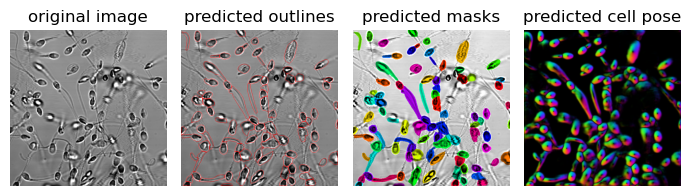

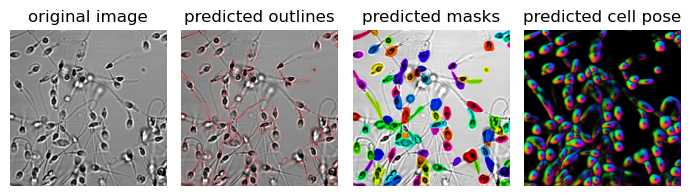

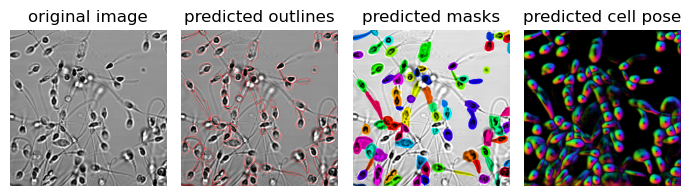

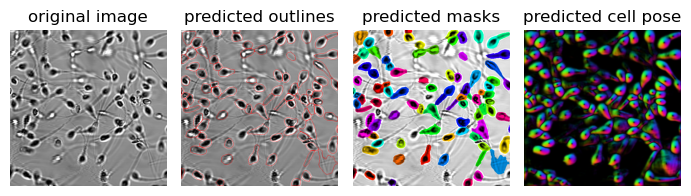

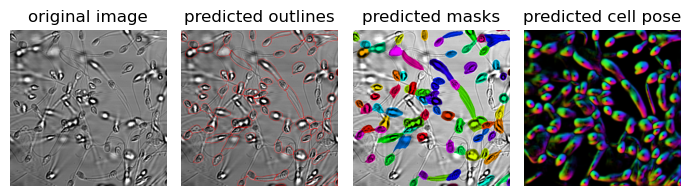

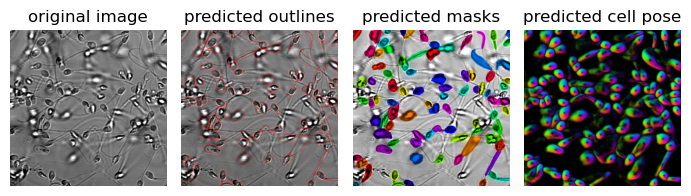

In [66]:
size = len(files_cell)//10
for i in range(size):
    fig = plt.figure(figsize=(7,5))
    plot.show_segmentation(fig, imgs_cell[i], masks[i], flows[i][0], channels=channels)
    plt.tight_layout()
    plt.show()

In [67]:
mask_path = r"C:\Users\zuzka\Desktop\2023_Vishma_FLIM_NADPH_sperms"
imwrite(mask_path + r'/' + folder_name + '_cellpose_mask.tif', masks) 